# Planet: a knob in, a world out

*A guided what-if over the capstone — the latitudinal climate of a planet, the bands of life it sets,
and the winds it organises.*

You turn two planetary knobs — **how bright the sun is** and **how much greenhouse gas is in the
air** — and the model hands back a whole world: a pole-to-equator **temperature profile**, the
**bands of life** that profile permits, and the **winds** rotation spins out of it. This notebook
walks that chain end to end and lets you turn the knobs: the solar constant, the greenhouse (OLR)
offset, the efficiency of heat transport.

Every number here comes from a function **validated in isolation** (`projects/planet/…`, each with
its own test triad — an analytic limit, a conservation/consistency law, a published benchmark). The
notebook is a *thin skin* (per [ADR 0002](../../docs/decisions/0002-visualization-and-ux.md)): each
compute cell calls the headless module directly, then `ipywidgets` sliders re-run that same code
live. The figures *consume* validated arrays — they are reach, not evidence.

The arc — the climate, the bifurcation it hides, the life it sets, and the winds it drives:

1. **The climate spine** — the latitudinal **energy-balance model** → the temperature profile
   `T(φ)` (`ebm`, `albedo`).
2. **The Snowball bifurcation** — one knob (the sun), **two stable climates**, a catastrophic jump
   (`demo_snowball`).
3. **Climate → habitability** — precip + the **Whittaker classifier** → the **biome map**
   (`precip`, `biomes`, `demo_biomes`).
4. **The winds** — the program's **second shared engine**, a rotating **shallow-water** solver:
   geostrophic adjustment and a westward Rossby wave (`circulation`, `demo_shallowwater`).
5. **The emergent jet** — couple the climate back to the fluid: its temperature gradient forces the
   flow and a **midlatitude jet emerges** (`coupler`, `demo_coupler`).
6. **The deep end** — the interactive 3-D globe (`planetmap`), and what comes next up the GCM
   staircase.

> This is the capstone: it reuses the **frozen `engines/diffusion` solver a third time** — the same
> parabolic solver that cooled Steel's Jominy bar and diffused Chip's dopant, now as a sphere's
> **pole-to-equator heat transport** — and it **builds the program's second shared engine**, the
> rotating shallow-water fluid solver (§4–5). Units are **SI / climlab-conventional**: W m⁻², °C,
> precipitation in cm/yr, and `x = sin φ` (the equal-area coordinate).

## Setup

Imports + the inline backend. The bootstrap walks up to the repo root so `projects.planet…` imports
whether you launched Jupyter from the repo root or from `projects/planet/`. Needs the `viz` +
`notebook` extras: `pip install -e .[viz,notebook]`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# Make `projects.planet…` importable regardless of the launch directory.
for _root in (Path.cwd(), *Path.cwd().parents):
    if (_root / "pyproject.toml").exists():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        break

from dataclasses import replace

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

from projects.planet import ebm, albedo, precip, biomes
from projects.planet import demo_snowball, demo_biomes, demo_shallowwater, demo_coupler
from projects.planet.albedo import EBMParams, present_day_climate
from projects.planet.ebm import A_OLR, S0_EARTH, D_TRANSPORT, T_FREEZE
from projects.planet.biomes import Biome, BIOME_NAMES
from projects.planet.plots import (profile_axes, snowball_figure, biomes_figure,
                                   shallowwater_figure, coupler_figure)

print(f"present-day defaults:  S₀ = {S0_EARTH:.1f} W/m²,  OLR offset A = {A_OLR:.0f} W/m²,  "
      f"transport D = {D_TRANSPORT:.3f} W/m²/K")

present-day defaults:  S₀ = 1365.2 W/m²,  OLR offset A = 210 W/m²,  transport D = 0.555 W/m²/K


## 1 — The climate spine: the energy-balance model

The planet's climate is one equation balanced at every latitude:

$$C\,\frac{\partial T}{\partial t} = \underbrace{D\,\frac{\partial}{\partial x}\!\Big[(1-x^2)\frac{\partial T}{\partial x}\Big]}_{\text{heat transport (the frozen engine)}} + \underbrace{S(x)\,(1-\alpha)}_{\text{absorbed sunlight}} - \underbrace{(A + B\,T)}_{\text{outgoing longwave}},\qquad x=\sin\varphi.$$

The **transport** term *is* a diffusion equation on the sphere — so it runs on the same frozen
`engines/diffusion` solver Steel and Chip used, here with insulated poles. The **radiation** is
composed *around* the engine by Strang operator splitting (the idiom Steel's Jominy bar reused for
its lateral heat loss). The one nonlinear piece is the **ice-albedo feedback**: the albedo α jumps
up where the surface freezes (`T < −10 °C`), so a colder pole reflects more sunlight and gets colder
still.

To *see* that feedback, the notebook overlays the **same climate with the feedback switched off**
(the albedo never flips to its high ice value). Where the planet is unfrozen the two curves nearly
coincide; the **iced pole pulls the real profile far below** — that gap is the feedback's bite.
Warm the planet until the ice cap vanishes and the curves **merge exactly**; dim it and they split.
(In that no-feedback limit the EBM even has an exact closed form — North's 1975 two-mode solution —
which the engine reproduces to 2nd order: the tight validation leg behind this panel.) The dramatic
consequences of the feedback are §2's job.

Turn the knobs: brighter/dimmer sun `S₀`, more/less greenhouse (a **lower** OLR offset `A` ≈ more
CO₂ → warmer), and the heat-transport efficiency `D` (higher `D` flattens the equator-to-pole
contrast).

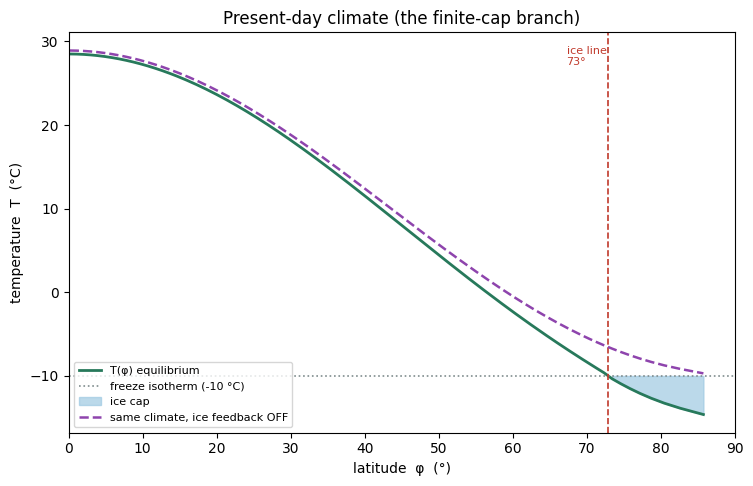

S₀ 1365 · A 210 · D 0.555  →  T̄ 14.70 °C · ice line 72.9° · net-TOA +2.0e-07 W/m²
   max |ice-on − ice-off| = 4.92 °C   (the gap IS the ice-albedo feedback; → 0 when the planet goes ice-free)


In [2]:
def climate_profile_what_if(S0=S0_EARTH, A=A_OLR, D=D_TRANSPORT):
    # Present-day EBM climate (ice feedback ON) vs the SAME climate with the feedback OFF.
    # n_tau=0.01 (fine): the steady state carries an O(Δt) operator-splitting bias, so this is the
    # one place NOT to coarsen — the on↔off gap must be the ice feedback, not numerics.
    params = EBMParams(S0=float(S0), A=float(A), D=float(D))
    ice_on = present_day_climate(params, n_tau=0.01)
    # Ice feedback OFF: push the freeze isotherm below any temperature, so α never switches to ice.
    ice_off = present_day_climate(replace(params, T_freeze=-1000.0), n_tau=0.01)
    lat = ice_on.latitude_deg()

    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    profile_axes(ax, ice_on)
    ax.plot(lat, ice_off.T, "--", color="#8e44ad", lw=1.8, label="same climate, ice feedback OFF")
    ax.legend(fontsize=8, loc="lower left")
    plt.show()

    gap = float(np.max(np.abs(ice_on.T - ice_off.T)))
    print(f"S₀ {S0:.0f} · A {A:.0f} · D {D:.3f}  →  "
          f"T̄ {ice_on.global_mean_T:.2f} °C · ice line {ice_on.ice_line_lat:.1f}° · "
          f"net-TOA {ice_on.net_toa:+.1e} W/m²")
    print(f"   max |ice-on − ice-off| = {gap:.2f} °C   "
          f"(the gap IS the ice-albedo feedback; → 0 when the planet goes ice-free)")

# Direct render (static, banked in the .ipynb).
climate_profile_what_if()

In [3]:
# Live: brighten/dim the sun, add greenhouse (lower A), change the heat-transport efficiency D.
interact(
    climate_profile_what_if,
    S0=widgets.FloatSlider(value=S0_EARTH, min=1200, max=1500, step=10,
                           description="S₀ W/m²", continuous_update=False),
    A=widgets.FloatSlider(value=A_OLR, min=190, max=220, step=2,
                          description="OLR A (lower=warmer)", continuous_update=False),
    D=widgets.FloatSlider(value=D_TRANSPORT, min=0.10, max=1.20, step=0.05,
                          description="transport D", continuous_update=False),
);

interactive(children=(FloatSlider(value=1365.2, continuous_update=False, description='S₀ W/m²', max=1500.0, mi…

## 2 — The Snowball bifurcation: one knob, two climates

Hidden inside that climate is a **bistability**. Dim the sun slowly and the ice cap creeps
equatorward — then past a threshold the ice-albedo feedback runs away and the **whole planet freezes
in a catastrophic jump** (Snowball Earth). Brighten it back and the white planet reflects so much
that it **stays frozen far past where it froze** — a wide hysteresis loop, *two stable climates for
one sun*.

This is the banked payoff and the integration test of every §1 piece (transport + the Strang-split
radiation + the feedback). It is a **parameter-continuation sweep** — ~120 equilibria, each
warm-started from the last — so it is **static, not a live slider**: a single `S₀` is a point, and
you need the whole loop to *see* the hysteresis. (The ★ is present-day Earth on the finite-cap
branch — a near-ice-free climate is also stable at today's sun.)

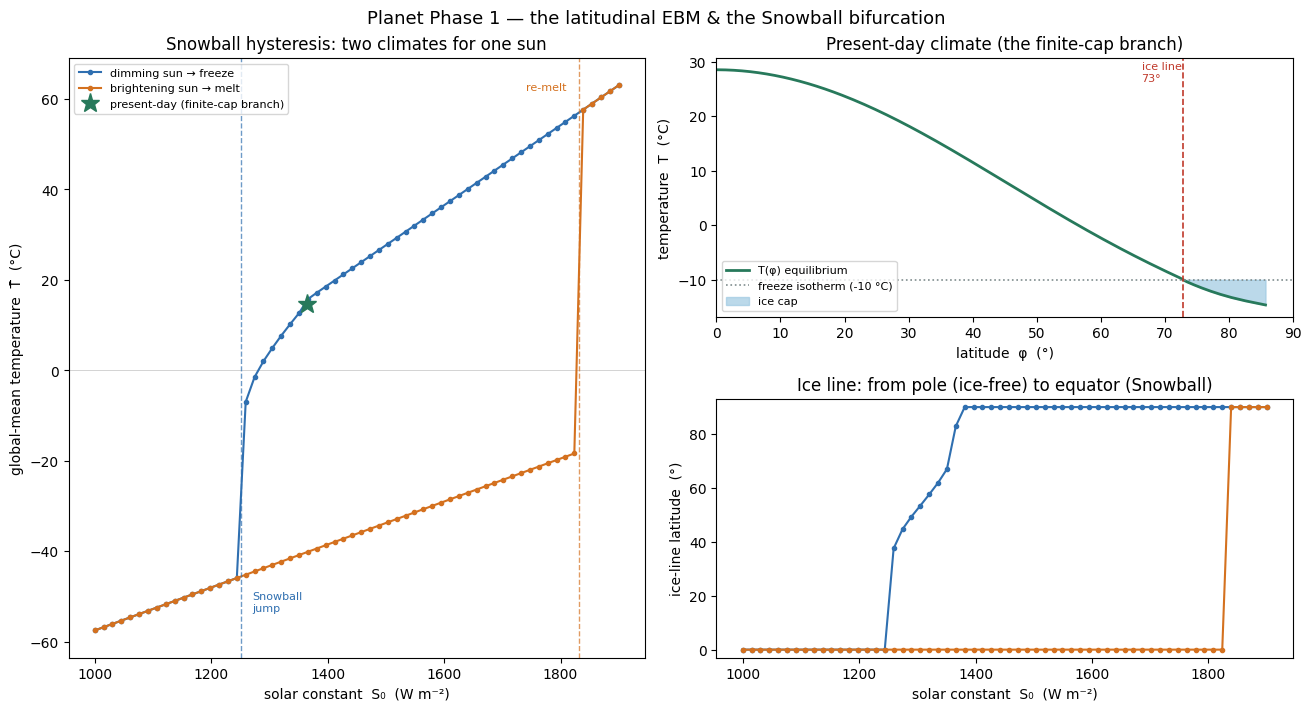

present-day:  T̄ 14.70 °C, ice line 72.9° (finite-cap branch; a near-ice-free climate is ALSO stable today)
freezes when dimmed to  S₀ ≈ 1252 W/m²  (−8.3%);  re-melts only at  S₀ ≈ 1831 W/m²   (hysteresis width 580 W/m²)
Snowball global-mean temperature: -57.5 °C  (a frozen white planet)


In [4]:
# The banked payoff: the full continuation sweep (dim → freeze, brighten → re-melt). ~3 s, static.
r = demo_snowball.compute()
snowball_figure(r.loop, r.present)
plt.show()
print(f"present-day:  T̄ {r.present.global_mean_T:.2f} °C, ice line {r.present_ice_line:.1f}° "
      f"(finite-cap branch; a near-ice-free climate is ALSO stable today)")
print(f"freezes when dimmed to  S₀ ≈ {r.freeze_S0:.0f} W/m²  (−{r.freeze_dimming_pct:.1f}%);  "
      f"re-melts only at  S₀ ≈ {r.melt_S0:.0f} W/m²   (hysteresis width {r.hysteresis_width:.0f} W/m²)")
print(f"Snowball global-mean temperature: {r.snowball_Tbar:.1f} °C  (a frozen white planet)")

## 3 — Climate → habitability: the biome map

Now the payoff the whole capstone builds toward. The climate state — the EBM temperature `T(φ)` and
a diagnostic precipitation `P(φ)` (`precip`: a circulation-set latitude pattern × a Clausius–Clapeyron
moisture amplitude) — is mapped through the **Whittaker classifier** (`biomes`) into a **biome at
every latitude**: tropical rain forest at the equator, the great deserts and savanna in the
subtropics, temperate forest in the midlatitudes, then boreal forest and tundra toward the poles.

*Planetary knobs in, bands of life out* — the planet analogue of Steel's microstructure and Chip's
device. And the bands **migrate as the knobs turn**: add greenhouse forcing (a CO₂ increase ≈ a
**lower** OLR offset `A`; a doubling ≈ 4 W/m²) and the tropics expand while the tundra retreats
poleward. The right panel is the *mechanism* — the Whittaker `(T, P)` plane with the planet's
equator→pole trajectory drawn through it, showing **why** the warm, dry subtropics land in desert.

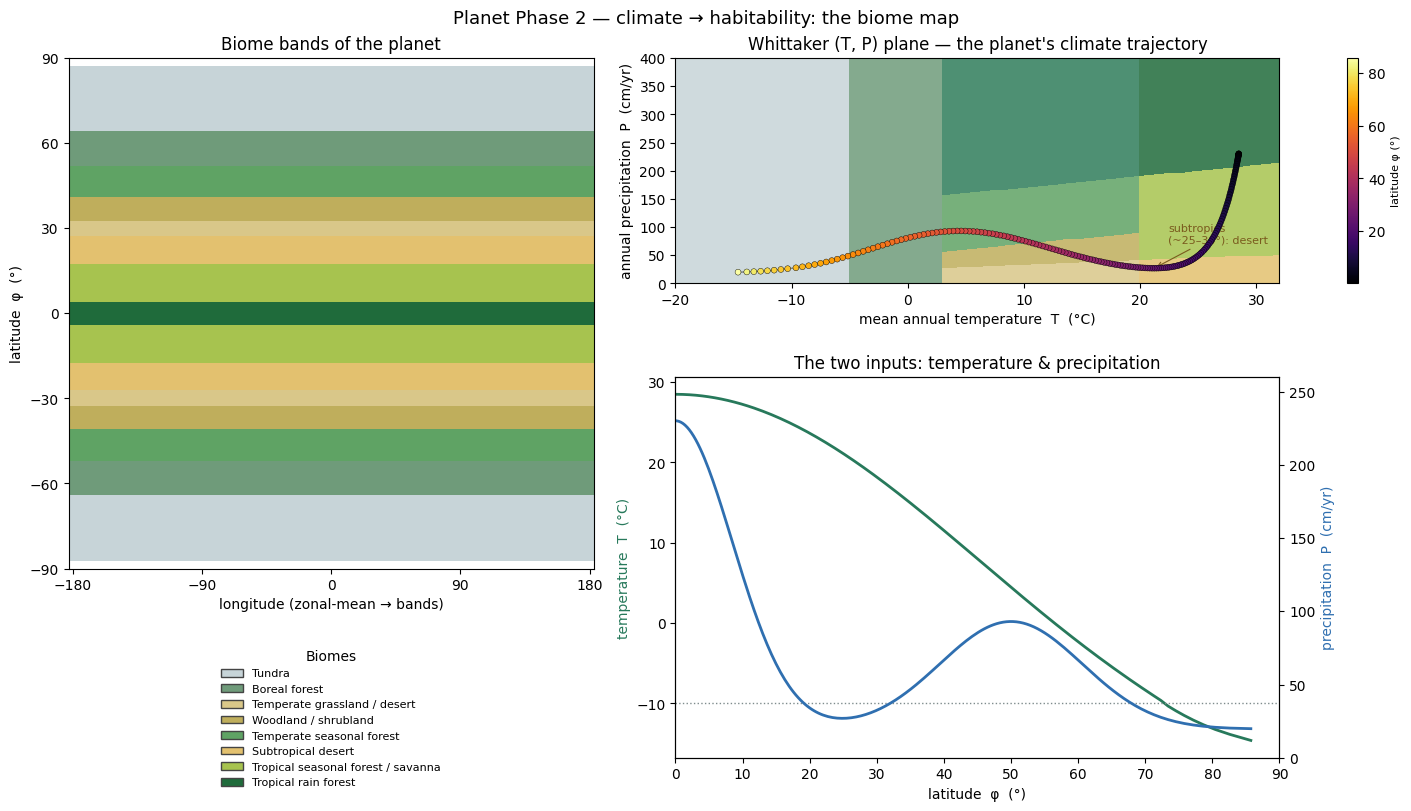

S₀ 1365 · CO₂ warming (−A) 0 W/m²  →  T̄ 14.70 °C · ice line 72.9°
   tropical rain forest 7.2% of the planet · tundra 10.0% · area fractions sum to 1.0000  (the map tiles the planet)


In [5]:
def biome_what_if(S0=S0_EARTH, co2_warming=0.0):
    # Climate → precip → biomes (demo_biomes.compute, the validated end-to-end map).
    # CO₂ up ≈ a drop in the OLR offset A. demo_biomes.compute uses the fine present-day n_tau internally.
    params = EBMParams(S0=float(S0), A=A_OLR - float(co2_warming))
    r = demo_biomes.compute(params)
    biomes_figure(r.state, r.precip_cm, r.codes)
    plt.show()

    rainforest = 100.0 * r.fraction(Biome.TROPICAL_RAIN_FOREST)
    tundra = 100.0 * r.fraction(Biome.TUNDRA)
    print(f"S₀ {S0:.0f} · CO₂ warming (−A) {co2_warming:.0f} W/m²  →  "
          f"T̄ {r.state.global_mean_T:.2f} °C · ice line {r.state.ice_line_lat:.1f}°")
    print(f"   tropical rain forest {rainforest:.1f}% of the planet · tundra {tundra:.1f}% · "
          f"area fractions sum to {sum(r.area_fractions.values()):.4f}  (the map tiles the planet)")

# Direct render (static, banked).
biome_what_if()

In [6]:
# Live: dim/brighten the sun, and crank the greenhouse — watch the biome bands migrate poleward.
interact(
    biome_what_if,
    S0=widgets.FloatSlider(value=S0_EARTH, min=1250, max=1450, step=10,
                           description="S₀ W/m²", continuous_update=False),
    co2_warming=widgets.FloatSlider(value=0.0, min=0.0, max=12.0, step=1.0,
                                    description="CO₂ warm (−A)", continuous_update=False),
);

interactive(children=(FloatSlider(value=1365.2, continuous_update=False, description='S₀ W/m²', max=1450.0, mi…

## 4 — The winds: the second shared engine

Everything so far runs on the **frozen diffusion solver** — energy in, energy out, redistributed by a
parabolic transport term. But a planet also has *fluid*: an atmosphere that rotates, and the winds
that rotation organises. This is the capstone's structural job — to **build and freeze the program's
second shared engine**, a rotating **shallow-water** solver (`engines/fluid`). It shares *no*
machinery with the diffusion spine: that one is parabolic and implicit; this one is **hyperbolic and
explicit** — a wave solver, CFL-limited, on a staggered Arakawa C-grid.

Two classic rotating-fluid demonstrations show it works (`circulation` pins the planetary numbers —
Earth's `f₀ = 2Ω sin φ`, `β = 2Ω cos φ / a`, and an equivalent depth giving the midlatitude
**deformation radius** `L_R ≈ 960 km`):

- **Geostrophic adjustment** — drop an unbalanced pressure bump into a rotating fluid at rest. It
  radiates most of its height away as inertia-gravity waves and **settles into a balanced vortex of
  scale `L_R`** — the analytic *Helmholtz-adjusted* state. Rotation is what stops it from simply
  spreading flat: the pressure gradient and Coriolis come into balance (`f × u = −g∇h`).
- **A Rossby wave** — nudge a large-scale balanced undulation and it drifts **westward**, the
  signature of the planetary-vorticity gradient β, at the analytic phase speed.

The conservation diagnostics hold throughout: **mass to machine precision**, energy and potential
enstrophy **bounded** (the symmetric scheme conserves energy semi-discretely — claims stated *as
measured*, the honest Phase-3 call). The match to the analytic Helmholtz state **tightens as the grid
refines**: at the notebook's coarse `nx = 48` it lands ~2 %, while the banked full-resolution figure
(`demo_shallowwater`) reaches ~1 %. *Convergence is part of the validation, not a fudge.*

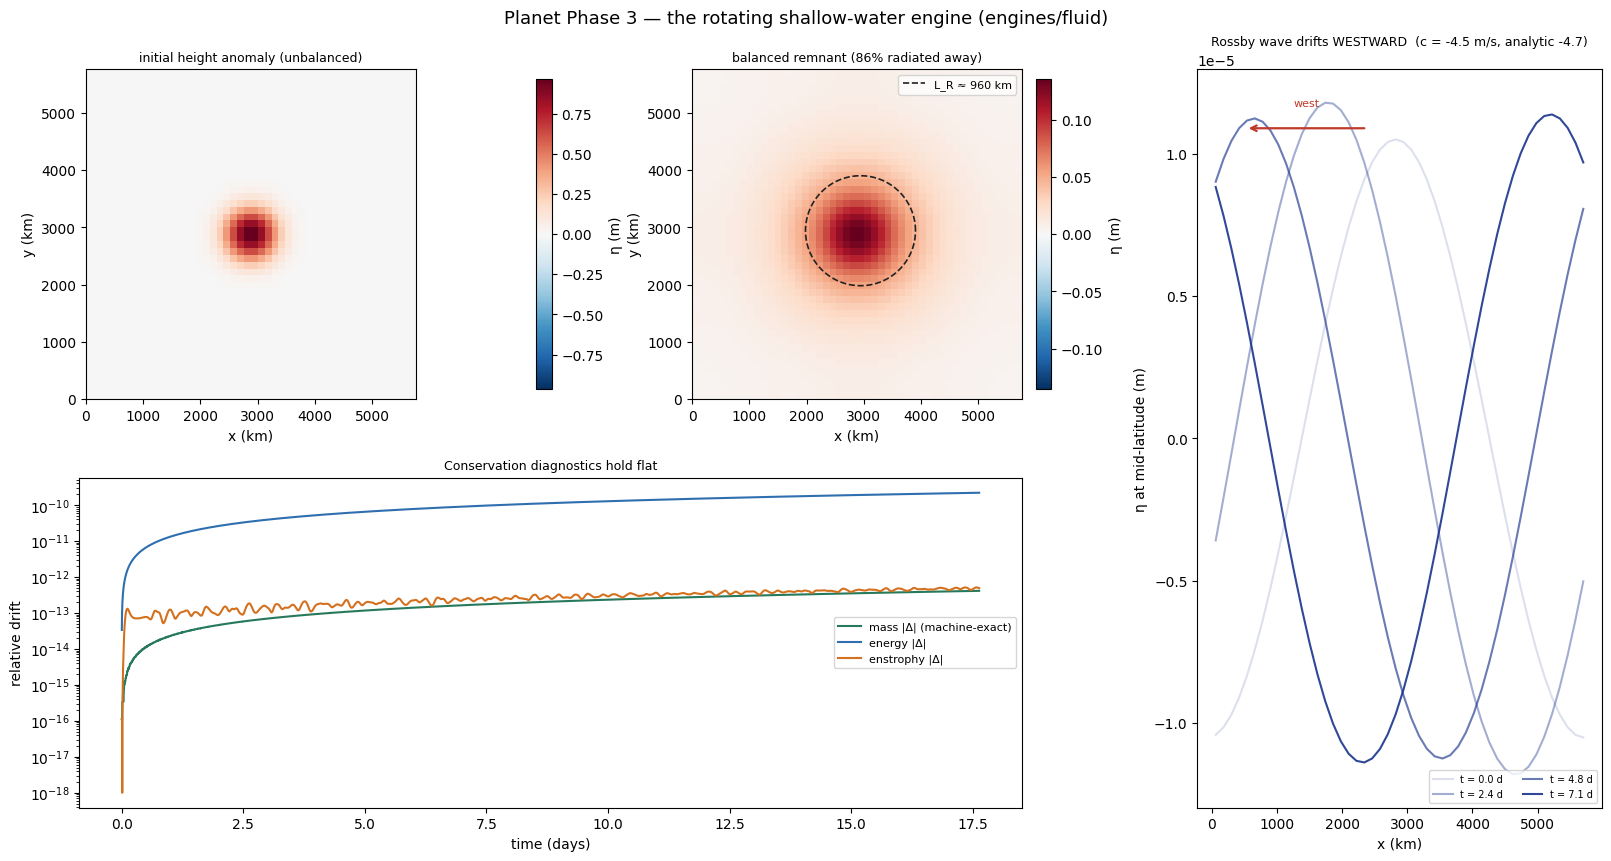

deformation radius  L_R = 960 km   (√(gH)/f₀, the midlatitude scale)
geostrophic adjustment:  86% of the bump radiated away as gravity waves;
   the balanced remnant matches the analytic Helmholtz state to 2.0% (→ ~1% at full resolution — it converges)
   mass drift 4.1e-13 (machine-exact) · energy 2.2e-10 · enstrophy 5.1e-13 (bounded)
Rossby wave:  phase speed c = -4.5 m/s WESTWARD  (analytic -4.7 m/s)


In [7]:
# The second shared engine, exercised with planetary numbers (geostrophic adjustment + a Rossby wave).
# Static, banked: a ~6 s integration at nx=48 (the demo banks the full-resolution figure). No live
# slider — like §2, the story is the whole run, not a point. compute → figure → show → print.
sw = demo_shallowwater.compute(nx=48, ny=48)
shallowwater_figure(sw.adjustment, sw.rossby)
plt.show()

a, ros = sw.adjustment, sw.rossby
print(f"deformation radius  L_R = {a.L_R/1e3:.0f} km   (√(gH)/f₀, the midlatitude scale)")
print(f"geostrophic adjustment:  {100*sw.drawdown_fraction:.0f}% of the bump radiated away as gravity waves;")
print(f"   the balanced remnant matches the analytic Helmholtz state to {100*sw.helmholtz_rel_error:.1f}% "
      f"(→ ~1% at full resolution — it converges)")
print(f"   mass drift {np.abs(a.mass).max():.1e} (machine-exact) · energy {np.abs(a.energy).max():.1e} · "
      f"enstrophy {np.abs(a.enstrophy).max():.1e} (bounded)")
print(f"Rossby wave:  phase speed c = {ros.c_measured:.1f} m/s WESTWARD  (analytic {ros.c_analytic:.1f} m/s)")

## 5 — The emergent jet: coupling climate to circulation

Now the capstone's closing move — **couple the two engines**. The diffusion spine gives an
equilibrium climate; its **meridional temperature gradient** (warm equator, cold pole) *is* a
pressure/height field; hand that to the rotating shallow-water engine, and rotation organises it into
a **midlatitude westerly jet** — the same physics as the real atmosphere's jet stream. *Climate in,
circulation out.*

The forcing is composed *around* the bare frozen engine by **operator splitting** — the third reuse
of the Strang idiom (Steel's Jominy lateral loss, then the EBM's radiation, now the coupler's thermal
relaxation + a weak drag). One-way only in v1 (climate → circulation); the two-way feedback is the
next rung of the GCM climb (§6).

Two things make this a real result rather than a placed feature:

- **The jet is *emergent*, not positioned.** The channel brackets the whole midlatitude zone, but the
  jet lands precisely at the **EBM temperature-gradient maximum** (~45°) — move the gradient and the
  jet follows it. It sits there because the physics puts it there.
- **Geostrophic balance is the anchor.** The steady jet satisfies `f·u ≈ −g·∂h/∂y` in its core (a
  few-percent residual) — the analytic check that the coupled flow is genuinely balanced.

**Honest edges.** The engine is doubly-periodic (no walls), so the westerly is flanked by a
compensating **easterly return** — net zonal momentum is near zero. The east–west sign banding
*resembles* the general circulation, but a single dry layer does **not** reproduce the observed
westerly-dominant magnitudes (a named scope edge). And conservation is **reframed** for a
forced–dissipative system: mass stays machine-exact under forcing, while energy and enstrophy are
*not* conserved (the forcing–drag balance is what *selects* the jet) — but a **release test** switches
the forcing off and the bare engine re-confirms all three invariants *while the jet persists*, proving
it is a balanced state, not a forcing-propped artifact.

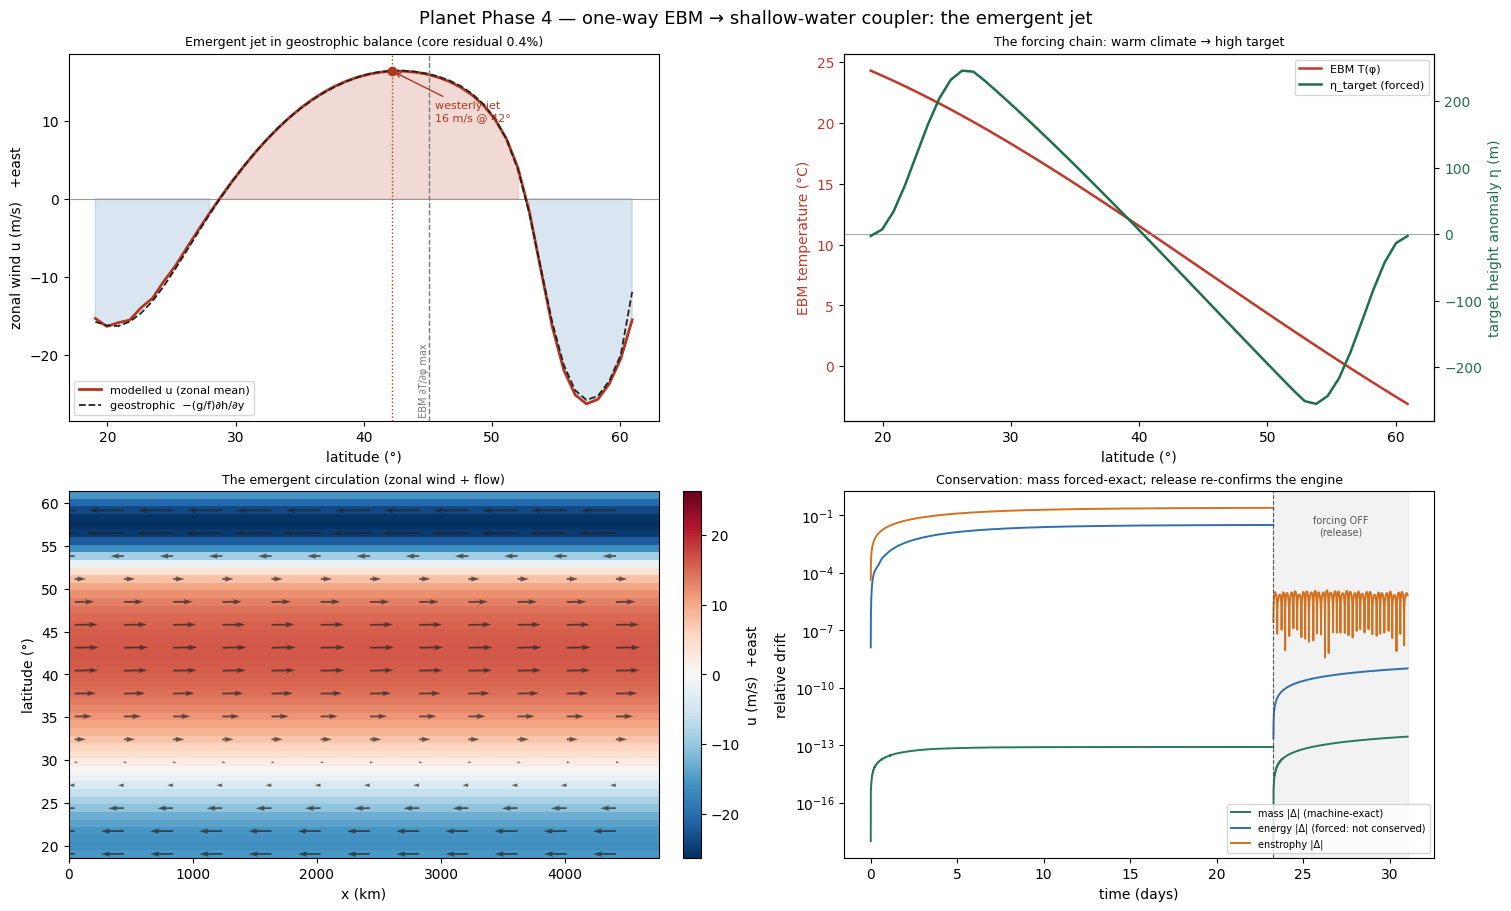

EBM climate:  T̄ 14.77 °C · ice line 72.8°
emergent westerly jet:  16.4 m/s @ 42.2°   (at the EBM ∂T/∂φ maximum 45.1° — emergent, NOT the channel centre)
   flanking easterly return -26.3 m/s · geostrophic core residual 0.4% (f·u ≈ −g ∂h/∂y, the anchor)
release test (forcing off):  mass 2.8e-13 · energy 1.0e-09 · enstrophy 1.2e-05 (engine invariants re-confirmed)
   jet persists:  16.4 → 16.4 m/s (a genuine balanced state, not forcing-propped)


In [8]:
# Couple the two engines: present-day EBM gradient → shallow-water → an emergent jet. Static, banked.
# A ~13 s spin-up at nx=48 (the demo banks the full-resolution figure + the interactive globe). Like
# §2/§4, no live slider — the plan makes the coupler computed-then-viewed (the first compute is too
# heavy for an instant remap). compute → figure → show → print (the slider-flicker order).
cp = demo_coupler.compute(nx=48, ny=48)
coupler_figure(cp.jet, cp.state)
plt.show()

j = cp.jet
print(f"EBM climate:  T̄ {cp.state.global_mean_T:.2f} °C · ice line {cp.state.ice_line_lat:.1f}°")
print(f"emergent westerly jet:  {j.jet_speed:.1f} m/s @ {j.jet_lat:.1f}°   "
      f"(at the EBM ∂T/∂φ maximum {j.gradient_peak_lat:.1f}° — emergent, NOT the channel centre)")
print(f"   flanking easterly return {j.u_profile.min():.1f} m/s · geostrophic core residual "
      f"{100*j.core_balance_residual:.1f}% (f·u ≈ −g ∂h/∂y, the anchor)")
print(f"release test (forcing off):  mass {np.abs(j.mass_release).max():.1e} · "
      f"energy {np.abs(j.energy_release).max():.1e} · enstrophy {np.abs(j.enstrophy_release).max():.1e} "
      f"(engine invariants re-confirmed)")
print(f"   jet persists:  {j.jet_speed:.1f} → {j.u_profile_release.max():.1f} m/s "
      f"(a genuine balanced state, not forcing-propped)")

## 6 — The deep end: the interactive globe

The biome map of §3 is *latitude bands* (a v1 **zonal-mean** planet). Its deep-end successor is
`projects/planet/planetmap.py` — a **Plotly 3-D globe** painted from a layer registry, with live
sliders that recompute the climate and repaint the world. It is opt-in (a separate `[webviz]` extra:
`pip install -e .[webviz]`) so this matplotlib notebook stays light, and ships a *pin-the-schema*
exporter (`planet_spec.py`) whose round-trip-identity test is the deep end's one real correctness
property.

Its slider panel now carries every knob in this notebook **and three more**: **obliquity** (axial
tilt → the insolation gradient, `obliquity.py`), the **host star's spectrum** (a redder star → a
darker ice albedo → harder to snowball), and **planet size** (→ transport only) — the exoplanet
sandbox. And §5's emergent jet rides the globe as a **`vector_overlay`** — wind cones over the
temperature field — the layer registry's extensibility proven by a layer *kind* the renderer was
built generic over. *(The globe lives in `planetmap.interactive_map` behind the `[webviz]` extra, so
this matplotlib notebook **describes** it rather than embedding it — the obliquity/exoplanet sliders
run there, not in the cells above.)*

> **What's next — up the GCM staircase (plan §5).** v1 is *rung 0*: a reduced, loosely-coupled
> climate. **Rung 1** is the **two-way coupler** — advect a temperature tracer in the fluid engine
> (the `tracer` slot is already declared, the seam built), close the poleward-heat-transport budget
> back to the EBM, and make precipitation *circulation-informed* rather than prescribed. Cheaper and
> parallel: make the **inert elevation** layer bite — a lapse-rate diagnostic `T_surf = T_band − Γ·z`
> plus a land/ocean albedo difference (no engine change). Each rung slots at the same plain-array
> seam; the map renderer, a pure array consumer, never changes.

## Where the numbers come from

Nothing here is fit in the notebook — every value is produced by a module validated in isolation,
each behind its own test triad (an analytic limit, a conservation/consistency law, a published
benchmark):

| Step | Module | Anchored to |
|---|---|---|
| Climate (EBM) | `ebm`, `albedo` | North (1975) **two-mode** analytic solution (~2nd order in Δx); global energy balance ⟨S(1−α)⟩ = A + B⟨T⟩ (net-TOA ~0); climlab present-day ice line ~70° |
| Snowball | `albedo`, `demo_snowball` | hysteresis **existence & structure** (two branches, a catastrophic jump, re-melt later than freeze); Voigt–Marotzke GCM dimming threshold 6–9% |
| Precipitation | `precip` | ITCZ-wet / subtropics-dry / midlat-wet / poles-dry band structure; **monotone** ⟨P⟩(T̄); Clausius–Clapeyron ~7 %/K (moisture capacity) |
| Biomes | `biomes` | **total partition** (area fractions sum to 1); independent canonical **probe points**; observed equator→pole band ordering |
| Winds (shallow-water) | `circulation`, `demo_shallowwater` | gravity-wave √(gH) + **Poincaré dispersion** ω²=f₀²+gHk²; **geostrophic adjustment** to the analytic Helmholtz state over `L_R` (~1% at full res); mass machine-exact, energy/enstrophy bounded; **westward** Rossby phase speed |
| Emergent jet (coupler) | `coupler`, `demo_coupler` | **geostrophic balance** of the emergent jet (`f·u ≈ −g∂h/∂y`); jet at the EBM gradient maximum (*emergent*); the **release test** (forcing off → engine invariants re-confirmed, the jet persists) |

The transport term reuses the **same frozen `engines/diffusion` solver** that cooled Steel's Jominy
bar and diffused Chip's dopant — here as a sphere's pole-to-equator heat transport — and the
radiation is grafted on with the **same Strang-splitting idiom** Steel's Jominy used for its lateral
heat loss (the §5 coupler reuses that idiom a third time). The winds of §4–5 run on the program's
**second** shared engine — the rotating shallow-water solver, **built and frozen here**, sharing no
machinery with the parabolic diffusion spine. Per [ADR 0002](../../docs/decisions/0002-visualization-and-ux.md)
the figures above are *reach*, not evidence: the triads test the numbers, then we draw them.

Run the full validation suite for planet with `python -m tools.gate planet`, or the demos for the
publication-quality static figures (`python -m projects.planet.demo_snowball`,
`python -m projects.planet.demo_biomes`, `python -m projects.planet.demo_shallowwater`,
`python -m projects.planet.demo_coupler`).